The contents of this notebook were created with assistance from Claude generative AI.

# Inter-Annotator Agreement — Cohen's, Fleiss', Krippendorff's

**Milestone 2 — Project Data 15.** This notebook quantifies the reliability of the
congestion-pricing **stance** annotations on the shared **first 50 items**
(`q0001`–`q0050`), now labeled by **all three human annotators** (Freya, Jaime,
Anita). It also compares the humans against the **Sonnet** model labels.

All agreement statistics use published library implementations — `scikit-learn`
(Cohen), `statsmodels` (Fleiss), and `krippendorff` (alpha) — not hand-coded
formulas.

### What these metrics measure
Raw percent agreement overstates reliability because annotators agree *by chance*
some of the time. The chance-corrected coefficients below all take the form
$\frac{\text{observed} - \text{chance}}{1 - \text{chance}}$: 1 is perfect, 0 is
chance-level, < 0 is worse than chance.

| Metric | Raters | Chance model | Library |
|---|---|---|---|
| **Cohen's $\kappa$** | exactly **2** | each rater's own marginal frequencies | `sklearn.metrics.cohen_kappa_score` |
| **Fleiss' $\kappa$** | **2+** (fixed # / item) | one pooled label distribution | `statsmodels …fleiss_kappa` |
| **Krippendorff's $\alpha$** | **2+**, missing data OK | pairwise coincidences; supports nominal **and ordinal** distance | `krippendorff.alpha` |

> **Data note:** Items `q0001`–`q0050` are now labeled by **Freya**, **Jaime**, and
> **Anita**, so this is a genuine **3-rater** analysis. Anita additionally labeled
> `q0051`+ alone; per the instructions we analyze **only the first 50** items where
> all three overlap. The **Sonnet** model labels come from the relabel-5k sidecar
> (`claude_stance`) and are used only for the separate human-vs-model comparison.

In [21]:
import json
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator

from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters
import krippendorff

pd.set_option("display.max_columns", 50)

# --- Config -----------------------------------------------------------------
DATA_DIR = Path.cwd()                         # notebook lives in the data folder
N_FIRST  = 50                                 # analyze the shared first 50 items
FIRST_IDS = [f"q{i:04d}" for i in range(1, N_FIRST + 1)]

HUMANS = {                                    # rater -> annotations file
    "Freya": "gold_labels_Freya_50.jsonl",
    "Jaime": "gold_labels_Jaime_51.jsonl",
    "Anita": "gold_labels_Anita_351.jsonl"
}
GOLD = {
    "Gold": "gold_labels_Anita_301.jsonl"
}
SIDECAR = (DATA_DIR.parent / "Project Data - 7 - Relabel 5k"
           / "gold_build" / "gold_adj_sidecar.parquet")

# Stance label space. mixed/unsure are hedge labels collapsed into neutral for the
# 4-class view; the polar order anti < neutral < pro drives the ordinal alpha.
FULL_ORDER  = ["pro", "anti", "neutral", "mixed", "unsure", "NA"]
FOUR_ORDER  = ["pro", "anti", "neutral", "NA"]
COLLAPSE    = {"mixed": "neutral", "unsure": "neutral"}
ORDINAL_MAP = {"anti": 0, "neutral": 1, "pro": 2}     # NA is off-scale -> dropped

UMICH = LinearSegmentedColormap.from_list("umich", ["#ffffff", "#00274C"])

print("Working directory:", DATA_DIR)
for name, fn in HUMANS.items():
    print(f"  {name:6s} -> {fn}  exists={(DATA_DIR/fn).exists()}")
print("  Sonnet sidecar ->", SIDECAR.name, " exists=", SIDECAR.exists())

Working directory: Project Data - 15 - Cohen's and Fleiss' kappa
  Freya  -> gold_labels_Freya_50.jsonl  exists=True
  Jaime  -> gold_labels_Jaime_51.jsonl  exists=True
  Anita  -> gold_labels_Anita_351.jsonl  exists=True
  Sonnet sidecar -> gold_adj_sidecar.parquet  exists= True


In [6]:
# --- Load human annotations into a wide (item x rater) label matrix ---------
def load_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return pd.DataFrame([json.loads(l) for l in f if l.strip()])

wide = pd.DataFrame({
    name: load_jsonl(DATA_DIR / fn).set_index("qid")["label"].reindex(FIRST_IDS)
    for name, fn in HUMANS.items() 
})

assert wide.notna().all().all(), "Some rater is missing a label on the first 50"
print(f"Analysis set: {FIRST_IDS[0]}–{FIRST_IDS[-1]}  ({len(wide)} items x "
      f"{wide.shape[1]} raters)")
wide.head(8)

Analysis set: q0001–q0050  (50 items x 3 raters)


,Freya,Jaime,Anita
qid,,,
q0001,pro,unsure,NA
q0002,neutral,neutral,neutral
q0003,anti,anti,neutral
q0004,anti,mixed,mixed
q0005,NA,NA,pro
q0006,pro,pro,mixed
q0007,pro,neutral,pro
q0008,pro,neutral,pro


## 1. Coverage & overlap diagnostics

Kappa/alpha require the *same items* rated by *different raters*. We confirm the
three-way overlap and look at each rater's label distribution before computing.

In [7]:
print("Items labeled per rater (full files):")
for name, fn in HUMANS.items():
    q = load_jsonl(DATA_DIR / fn)["qid"]
    print(f"  {name:6s}: n={q.nunique():4d}  range {q.min()}–{q.max()}")

triple = set.intersection(*[
    set(load_jsonl(DATA_DIR / fn)["qid"]) for fn in HUMANS.values()])
print(f"\nItems rated by ALL THREE humans: {len(triple)} "
      f"(>= {N_FIRST} required for the first-50 analysis)")

# Per-rater label distribution on the analysis set
dist = wide.apply(lambda c: c.value_counts()).fillna(0).astype(int)
dist.loc["TOTAL"] = dist.sum()
print("\nLabel distribution on the first 50:")
dist

Items labeled per rater (full files):
  Freya : n=  50  range q0001–q0050
  Jaime : n=  51  range q0001–q0051
  Anita : n= 351  range q0001–q0351

Items rated by ALL THREE humans: 50 (>= 50 required for the first-50 analysis)

Label distribution on the first 50:


,Freya,Jaime,Anita
NA,4,5,1
anti,9,11,7
mixed,1,5,9
neutral,13,9,26
pro,23,18,7
unsure,0,2,0
TOTAL,50,50,50


## 2. Helpers

A single confusion-chart routine (used for every pair) and small wrappers around
the library agreement functions, so the nominal and 4-class views are computed
identically.

In [86]:
def collapse(df_or_s):
    f = lambda x: COLLAPSE.get(x, x)
    return df_or_s.map(f) if isinstance(df_or_s, pd.Series) else df_or_s.apply(lambda c: c.map(f))

def confusion_chart(a, b, a_name, b_name, order, fname, n_label=None, vmax=None, nbins=5):
    
    "Heatmap with rows=a, cols=b; subtitle carries raw agreement + Cohen's kappa."
    n = len(a)
    cm = pd.crosstab(a, b).reindex(index=order, columns=order, fill_value=0)
    acc = np.trace(cm.values) / n
    k = cohen_kappa_score(a, b, labels=order)
    M, K = cm.values, len(order)
    fig, ax = plt.subplots(figsize=(5.2, 3.4)) ###################
    ax.imshow(M, cmap=UMICH, vmin=0, vmax=M.max())
    ax.set_xticks(range(K)); ax.set_yticks(range(K))
    ax.set_xticklabels(order); ax.set_yticklabels(order)
    ax.set_xlabel(f"{b_name} label", fontweight="bold", fontsize=10)
    ax.set_ylabel(f"{a_name} label", fontweight="bold", fontsize=10)
    ax.set_title(f"{a_name} vs {b_name} — Stance Confusion "
                 f"(n={n_label or n})\nraw agreement={acc:.1%}   "
                 rf"Cohen $\kappa$={k:.2f}", fontsize=11, pad=10)
    thr = M.max() * 0.55
    for i in range(K):
        for j in range(K):
            v = M[i, j]
            ax.text(j, i, str(v), ha="center", va="center",
                    color="white" if v > thr else "#00274C",
                    fontweight="bold" if i == j else "normal", fontsize=12)
    for s in ax.spines.values(): s.set_visible(False)
    ax.set_xticks(np.arange(-.5, K, 1), minor=True)
    ax.set_yticks(np.arange(-.5, K, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", length=0)
    im = ax.imshow(M, cmap=UMICH, vmin=0, vmax=vmax or M.max())
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("count")
    cb.locator = MaxNLocator(nbins=nbins, integer=True) 
    cb.update_ticks() 
    plt.tight_layout()
    plt.savefig(DATA_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()
    return cm, acc, k

def fleiss(wide_df):
    table, _ = aggregate_raters(wide_df.values)
    return fleiss_kappa(table, method="fleiss")

def kripp_nominal(wide_df):
    cats = sorted(set(wide_df.values.ravel()))
    code = {c: i for i, c in enumerate(cats)}
    rel = np.array([[code[v] for v in wide_df[r]] for r in wide_df.columns])
    return krippendorff.alpha(reliability_data=rel, level_of_measurement="nominal")

def kripp_ordinal(wide_df):
    "Ordinal alpha on the anti<neutral<pro scale; items with any NA are dropped."
    mask = wide_df.apply(lambda c: c.isin(ORDINAL_MAP)).all(axis=1)
    sub = wide_df[mask]
    rel = np.array([[ORDINAL_MAP[v] for v in sub[r]] for r in sub.columns])
    return krippendorff.alpha(reliability_data=rel, level_of_measurement="ordinal"), int(mask.sum())

def mean_pairwise_cohen(wide_df):
    ks = [cohen_kappa_score(wide_df[a], wide_df[b])
          for a, b in combinations(wide_df.columns, 2)]
    return float(np.mean(ks))

## 3. Pairwise Cohen's kappa (humans)

Cohen's $\kappa$ is the standard chance-corrected agreement for **two** raters, using
each rater's own marginal frequencies as the chance model. We report all three
human pairs on both the full label set and the 4-class collapse.

In [80]:
def pairwise_table(wide_df):
    rows = []
    for a, b in combinations(wide_df.columns, 2):
        k = cohen_kappa_score(wide_df[a], wide_df[b])
        po = (wide_df[a] == wide_df[b]).mean()
        rows.append({"pair": f"{a} vs {b}", "raw_agreement": round(po, 3),
                     "cohen_kappa": round(k, 3)})
    df = pd.DataFrame(rows)
    df.loc[len(df)] = {"pair": "MEAN", "raw_agreement": round(df.raw_agreement.mean(), 3),
                       "cohen_kappa": round(df.cohen_kappa.mean(), 3)}
    return df

wide4 = collapse(wide)
print("Full label set:")
display(pairwise_table(wide))
print("4-class collapsed (mixed, unsure -> neutral):")
display(pairwise_table(wide4))

Full label set:


,pair,raw_agreement,cohen_kappa
0,Freya vs Jaime,0.500,0.322
1,Freya vs Anita,0.380,0.195
2,Jaime vs Anita,0.420,0.280
3,MEAN,0.433,0.266


4-class collapsed (mixed, unsure -> neutral):


,pair,raw_agreement,cohen_kappa
0,Freya vs Jaime,0.540,0.340
1,Freya vs Anita,0.400,0.158
2,Jaime vs Anita,0.460,0.221
3,MEAN,0.467,0.240


### Pairwise confusion charts (4-class)

The single $\kappa$ per pair hides *where* raters diverge. These heatmaps localize
it — on this data the disagreement concentrates on the **neutral ↔ polar
(pro/anti)** boundary, and Anita uses **neutral** more than the others.

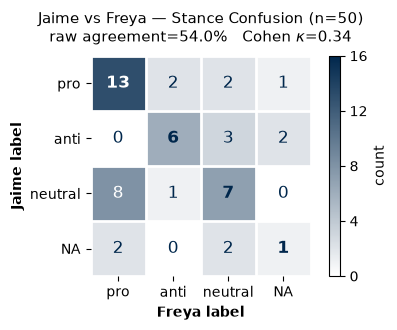

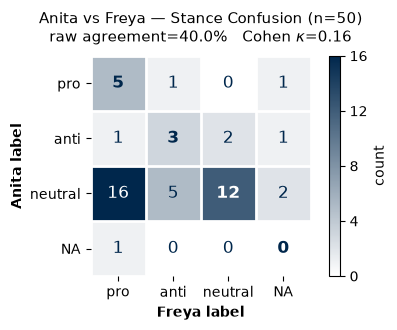

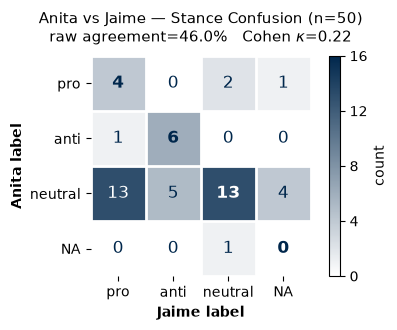

In [87]:
for a, b in combinations(wide4.columns, 2):
    fname = f"confusion_{b.lower()}_vs_{a.lower()}_4class.png"
    confusion_chart(wide4[b], wide4[a], b, a, FOUR_ORDER, fname, vmax=16, nbins=5)

## 4. Fleiss' kappa & Krippendorff's alpha (3 humans)

With a complete, balanced 3-rater design these two coefficients should land very
close together — a useful mutual sanity check. Krippendorff additionally gives an
**ordinal** variant that credits near-miss disagreements (pro↔neutral counts less
than pro↔anti) on the `anti < neutral < pro` scale.

In [91]:
wide4.tail()

,Freya,Jaime,Anita
qid,,,
q0046,neutral,neutral,neutral
q0047,pro,pro,neutral
q0048,neutral,anti,anti
q0049,pro,pro,neutral
q0050,pro,neutral,neutral


In [92]:
wide.tail()

,Freya,Jaime,Anita
qid,,,
q0046,mixed,mixed,mixed
q0047,pro,pro,neutral
q0048,neutral,anti,anti
q0049,pro,pro,mixed
q0050,pro,mixed,neutral


In [82]:
# Ordinal alpha is ALWAYS measured on the 3-point anti < neutral < pro scale —
# it never sees 4 classes. Per the analysis spec, mixed/unsure are folded into
# neutral and items where any rater used NA are dropped, leaving n=41 on that
# 3-point scale. (The label_set column below describes the *nominal* groupings;
# the ordinal row is its own 3-point scale, hence listed separately.)
ord_alpha, n_ord = kripp_ordinal(wide4)

multi = pd.DataFrame([
    {"label_set": "full (6-cat)", "metric": "Fleiss' kappa",
     "value": round(fleiss(wide), 3)},
    {"label_set": "full (6-cat)", "metric": "Krippendorff alpha (nominal)",
     "value": round(kripp_nominal(wide), 3)},
    {"label_set": "4-class",      "metric": "Fleiss' kappa",
     "value": round(fleiss(wide4), 3)},
    {"label_set": "4-class",      "metric": "Krippendorff alpha (nominal)",
     "value": round(kripp_nominal(wide4), 3)},
    {"label_set": "3-pt (anti<neutral<pro)",
     "metric": f"Krippendorff alpha (ordinal, NA dropped, n={n_ord})",
     "value": round(ord_alpha, 3)},
])
multi

,label_set,metric,value
0,full (6-cat),Fleiss' kappa,0.243
1,full (6-cat),Krippendorff alpha (nominal),0.248
2,4-class,Fleiss' kappa,0.208
3,4-class,Krippendorff alpha (nominal),0.213
4,3-pt (anti<neutral<pro),"Krippendorff alpha (ordinal, NA dropped, n=41)",0.422


## 5. Bootstrap confidence intervals

With only $N=50$ items the point estimates have wide uncertainty, so a bare "Fair"
label is overconfident. We resample the 50 items **with replacement** (5,000×) and
report 95% percentile intervals for the 3-rater coefficients and the mean pairwise
Cohen's $\kappa$. Degenerate resamples (a single category present → undefined
chance correction) are dropped.

In [83]:
def bootstrap_ci(wide_df, stat_fn, B=5000, seed=0):
    rng = np.random.default_rng(seed)
    n = len(wide_df); idx = np.arange(n); vals = []
    for _ in range(B):
        try:
            s = stat_fn(wide_df.iloc[rng.choice(idx, n, replace=True)])
        except Exception:
            continue                     # degenerate resample (e.g. all-NA after filter)
        if s == s:                       # skip NaN
            vals.append(s)
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return np.mean(vals), lo, hi, len(vals)

# Ordinal alpha on the 3-point anti<neutral<pro scale: mixed/unsure already folded
# into neutral (wide4), and items where any rater used NA are dropped inside the fn.
ord_scalar = lambda wd: kripp_ordinal(wd)[0]

specs = [
    ("Fleiss' kappa",             "full",    wide,  fleiss),
    ("Krippendorff a (nominal)",  "full",    wide,  kripp_nominal),
    ("Mean pairwise Cohen kappa", "full",    wide,  mean_pairwise_cohen),
    ("Fleiss' kappa",             "4-class", wide4, fleiss),
    ("Krippendorff a (nominal)",  "4-class", wide4, kripp_nominal),
    ("Mean pairwise Cohen kappa", "4-class", wide4, mean_pairwise_cohen),
    ("Krippendorff a (ordinal)",  "3-pt (anti<neutral<pro)", wide4, ord_scalar),
]
rows = []
for metric, ls, wd, fn in specs:
    point = fn(wd)
    mean, lo, hi, b = bootstrap_ci(wd, fn)
    rows.append({"metric": metric, "label_set": ls, "point": round(point, 3),
                 "boot_mean": round(mean, 3), "ci95_lo": round(lo, 3),
                 "ci95_hi": round(hi, 3), "n_boot": b})
ci = pd.DataFrame(rows)
ci

,metric,label_set,point,boot_mean,ci95_lo,ci95_hi,n_boot
0,Fleiss' kappa,full,0.243,0.236,0.122,0.357,5000
1,Krippendorff a (nominal),full,0.248,0.241,0.127,0.362,5000
2,Mean pairwise Cohen kappa,full,0.266,0.263,0.162,0.374,5000
3,Fleiss' kappa,4-class,0.208,0.201,0.072,0.342,5000
4,Krippendorff a (nominal),4-class,0.213,0.206,0.078,0.346,5000
5,Mean pairwise Cohen kappa,4-class,0.240,0.238,0.128,0.364,5000
6,Krippendorff a (ordinal),3-pt (anti<neutral<pro),0.422,0.410,0.202,0.592,5000


## 6. Human vs Sonnet (model) comparison

Kept separate from the human reliability figures above. We join Anita's labels to
the model's `claude_stance` (Sonnet) on `qid` and show the confusion in both the
5-class and 4-class views. (Annotators saw fuller context than Sonnet did, by
design, so part of any gap is an information asymmetry, not pure label error.)

Gold ∩ Sonnet items: 301


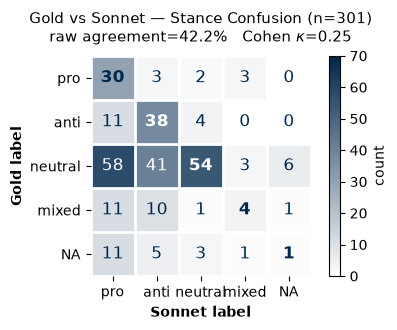

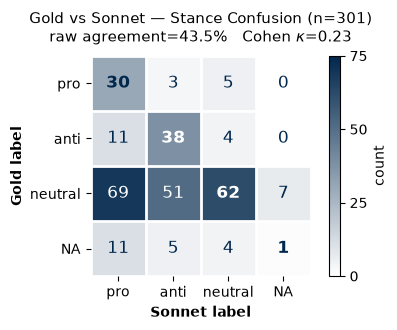

Anita ∩ Sonnet items: 301


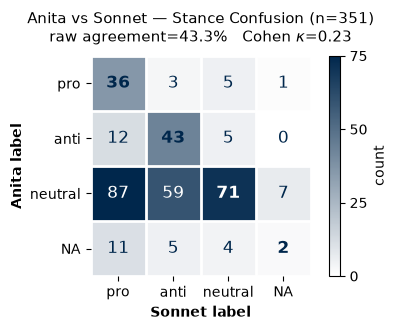

(claude_stance  pro  anti  neutral  NA
 label                                
 pro             36     3        5   1
 anti            12    43        5   0
 neutral         87    59       71   7
 NA              11     5        4   2,
 np.float64(0.43304843304843305),
 0.23049211752652277)

In [88]:
side = pd.read_parquet(SIDECAR)[["qid", "claude_stance"]]
gold_all = load_jsonl(DATA_DIR / GOLD["Gold"])[["qid", "label"]]
hm = gold_all.merge(side, on="qid", how="inner")
print(f"Gold ∩ Sonnet items: {len(hm)}")

FIVE_ORDER = ["pro", "anti", "neutral", "mixed", "NA"]
confusion_chart(hm["label"], hm["claude_stance"], "Gold", "Sonnet",
                FIVE_ORDER, "confusion_gold_vs_sonnet_5class.png", vmax=70, nbins=8)
confusion_chart(collapse(hm["label"]), collapse(hm["claude_stance"]),
                "Gold", "Sonnet", FOUR_ORDER, "confusion_gold_vs_sonnet_4class.png", vmax=75, nbins=3)

anita_all = load_jsonl(DATA_DIR / HUMANS["Anita"])[["qid", "label"]]
an = anita_all.merge(side, on="qid", how="inner")
print(f"Anita ∩ Sonnet items: {len(hm)}")
confusion_chart(collapse(an["label"]), collapse(an["claude_stance"]),
                "Anita", "Sonnet", FOUR_ORDER, "confusion_anita_vs_sonnet_4class.png", vmax=75, nbins=3)

Jaime ∩ Sonnet items: 50
Freya ∩ Sonnet items: 50


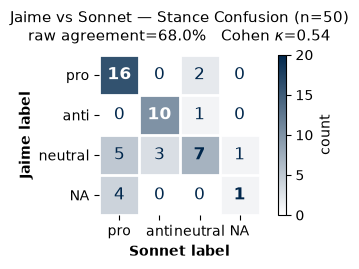

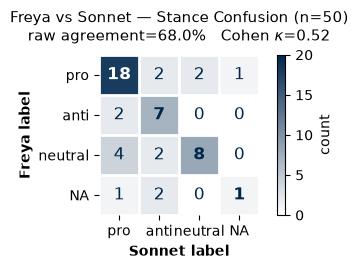

(claude_stance  pro  anti  neutral  NA
 label                                
 pro             18     2        2   1
 anti             2     7        0   0
 neutral          4     2        8   0
 NA               1     2        0   1,
 np.float64(0.68),
 0.5180722891566265)

In [85]:
side = pd.read_parquet(SIDECAR)[["qid", "claude_stance"]]
jaime_all = load_jsonl(DATA_DIR / HUMANS["Jaime"])[["qid", "label"]][:50]
jm = jaime_all.merge(side, on="qid", how="inner")
print(f"Jaime ∩ Sonnet items: {len(jm)}")

freya_all = load_jsonl(DATA_DIR / HUMANS["Freya"])[["qid", "label"]][:50]
fr = freya_all.merge(side, on="qid", how="inner")
print(f"Freya ∩ Sonnet items: {len(fr)}")

confusion_chart(collapse(jm["label"]), collapse(jm["claude_stance"]),
                "Jaime", "Sonnet", FOUR_ORDER, "confusion_jaime_vs_sonnet_4class.png", vmax=20, nbins=4)
# confusion_chart(collapse(jm["label"]), collapse(jm["claude_stance"]),
#                 "Jaime", "Sonnet", FIVE_ORDER, "confusion_jaime_vs_sonnet_5class.png", vmax=20, nbins=3)
## Freya
confusion_chart(collapse(fr["label"]), collapse(fr["claude_stance"]),
                "Freya", "Sonnet", FOUR_ORDER, "confusion_freya_vs_sonnet_4class.png", vmax=20, nbins=4)
# confusion_chart(collapse(fr["label"]), collapse(fr["claude_stance"]),
#                 "Freya", "Sonnet", FIVE_ORDER, "confusion_freya_vs_sonnet_5class.png", vmax=20, nbins=3)

Anita ∩ Sonnet items: 50


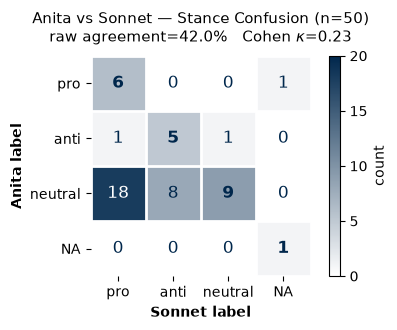

(claude_stance  pro  anti  neutral  NA
 label                                
 pro              6     0        0   1
 anti             1     5        1   0
 neutral         18     8        9   0
 NA               0     0        0   1,
 np.float64(0.42),
 0.22954303931987252)

In [89]:

anita_all = load_jsonl(DATA_DIR / HUMANS["Anita"])[["qid", "label"]][:50]
ana = anita_all.merge(side, on="qid", how="inner")
print(f"Anita ∩ Sonnet items: {len(ana)}")

confusion_chart(collapse(ana["label"]), collapse(ana["claude_stance"]),
                "Anita", "Sonnet", FOUR_ORDER, "confusion_anita50_vs_sonnet_4class.png", vmax=20, nbins=4)

## 7. Summary & interpretation

In [10]:
def band(x):
    if x < 0:     return "Poor"
    if x <= 0.20: return "Slight"
    if x <= 0.40: return "Fair"
    if x <= 0.60: return "Moderate"
    if x <= 0.80: return "Substantial"
    return "Almost perfect"

head = ci[ci.label_set == "4-class"].copy()
head["Landis-Koch"] = head["point"].map(band)
head["ci95"] = head.apply(lambda r: f"[{r.ci95_lo:.2f}, {r.ci95_hi:.2f}]", axis=1)
print("Headline 4-class human agreement (with 95% bootstrap CI):")
head[["metric", "point", "ci95", "Landis-Koch"]]

Headline 4-class human agreement (with 95% bootstrap CI):


,metric,point,ci95,Landis-Koch
3,Fleiss' kappa,0.208,"[0.07, 0.34]",Fair
4,Krippendorff a (nominal),0.213,"[0.08, 0.35]",Fair
5,Mean pairwise Cohen kappa,0.240,"[0.13, 0.36]",Fair
